# Introduction

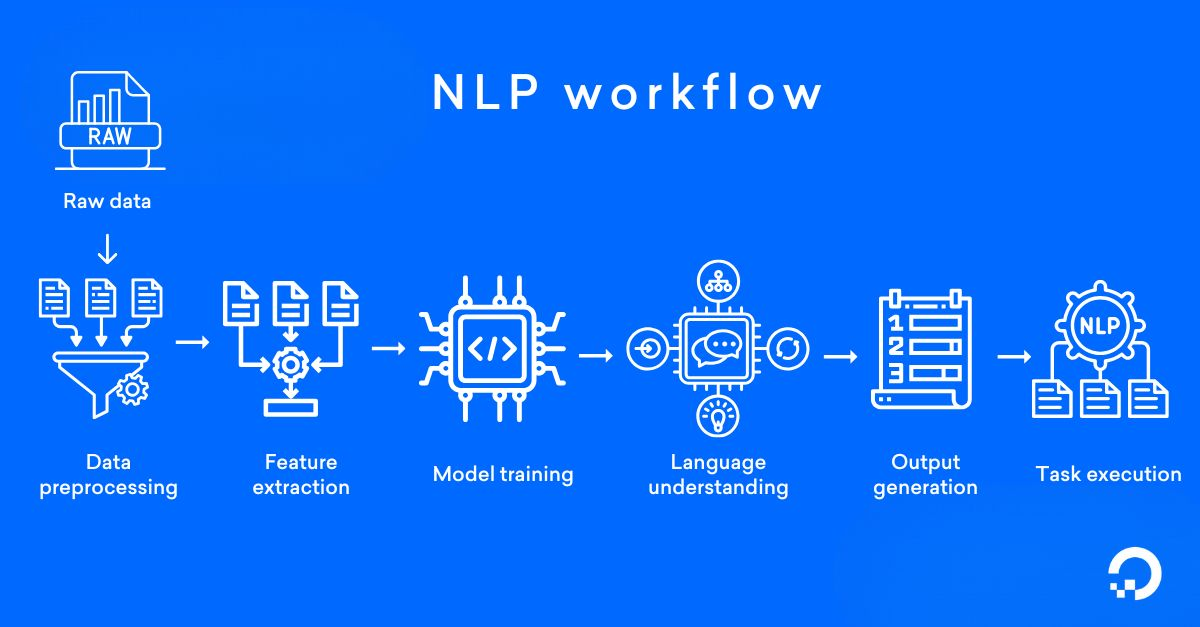

For my CST4812 Final project, I will be using the [Game of Thrones - Book Dataset](https://www.kaggle.com/datasets/saurabhbadole/game-of-thrones-book-dataset/data?select=1+-+A+Game+of+Thrones.txt) from Kaggle. The purpose for this is to perform **text generation** with a book from the epic fantasy series, Game of Thrones. The first book, A Game of Thrones, written by George R. R. Martin has 1,607,894 characters. I will be experimenting with PyTorch, Architecture: Vanilla RNN vs LSTM, Depth: Single-layer vs Stacked LSTM, Capacity: Hidden Dimension, and Sampling: Temperature and Top-k.

# 1.) Housing Imports and Setups

In [81]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math, random, time, re
import matplotlib.pyplot as plt

In [82]:
#reproducibility
random.seed(42); np.random.seed(42); torch.manual_seed(42)

In [83]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cpu | PyTorch: 2.10.0+cpu


# 2.) Textfile and Corpus

In [84]:
text   = open('1 - A Game of Thrones.txt', encoding='utf-8', errors='ignore').read()
corpus = re.sub(r'[^\x00-\x7f]', '', text.lower().replace('\r\n', '\n'))

In [85]:
# ── Slice corpus for faster training ─────────────────────────────
corpus = corpus[:75_000]

In [86]:
print(f'Corpus length: {len(corpus):,} characters')
print(f'\nSample (first 300 chars):\n{corpus[:300]}')

Corpus length: 75,000 characters

Sample (first 300 chars):
a game of thrones 
book one of a song of ice and fire 
by george r. r. martin 
prologue 
"we should start back," gared urged as the woods began to grow dark around them. "the wildlings are 
dead." 
"do the dead frighten you?" ser waymar royce asked with just the hint of a smile. 
gared did not rise 


# 3.) Character Tokenization, Encoding, and Splitting

Each unique character = one token. A split is sequential as a random shuffling would destroy the structure the RNN learns from.
- **Train**: 80% | **Validation**: 10% | **Test**: 10%

In [87]:
chars       = sorted(list(set(corpus)))
VOCAB_SIZE  = len(chars)
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}
encoded     = np.array([char_to_int[c] for c in corpus])

In [88]:
n          = len(encoded)
train_data = encoded[:int(n * 0.80)]
val_data   = encoded[int(n * 0.80):int(n * 0.90)]
test_data  = encoded[int(n * 0.90):]

In [89]:
print(f'Vocab size: {VOCAB_SIZE} unique characters')
print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}')

Vocab size: 47 unique characters
Train: 60,000 | Val: 7,500 | Test: 7,500


# 4.) Dataset and Loading

Each sample = sliding window of `SEQ_LENGTH` chars.
Input X = chars `[i : i+SEQ_LENGTH]`, Target Y = chars `[i+1 : i+SEQ_LENGTH+1]`.
This is self-supervised as the next character is the label.

In [90]:
SEQ_LENGTH = 75
BATCH_SIZE = 256

class CharDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.long)
    def __len__(self):
        return len(self.data) - SEQ_LENGTH
    def __getitem__(self, i):
        return self.data[i:i+SEQ_LENGTH], self.data[i+1:i+SEQ_LENGTH+1]

train_loader = DataLoader(CharDataset(train_data), BATCH_SIZE, shuffle=True,  drop_last=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(CharDataset(val_data),   BATCH_SIZE, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(CharDataset(test_data),  BATCH_SIZE, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader):,} | Val: {len(val_loader):,} | Test: {len(test_loader):,}')

Train batches: 234 | Val: 29 | Test: 29


# 5.) Model Definitions

**Vanilla Recurrent Neural Network**: `hₜ = g(Wxₜ + Uhₜ₋₁)` → `yₜ = f(Vhₜ)`

**Long Short Term Memory**: `Cₜ = Cₜ₋₁ ⊙ fₜ + C̃ₜ ⊙ iₜ` | `hₜ = oₜ ⊙ tanh(Cₜ)`

In [91]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim; self.n_layers = n_layers; self.is_lstm = False
        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        self.rnn        = nn.RNN(embed_dim, hidden_dim, n_layers, batch_first=True,
                                 dropout=dropout if n_layers > 1 else 0)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, h):
        o, h = self.rnn(self.embedding(x), h)
        return self.fc(self.dropout(o)), h
    def init_hidden(self, bs):
        return torch.zeros(self.n_layers, bs, self.hidden_dim).to(DEVICE)

In [92]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim; self.n_layers = n_layers; self.is_lstm = True
        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True,
                                  dropout=dropout if n_layers > 1 else 0)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, h):
        o, h = self.lstm(self.embedding(x), h)
        return self.fc(self.dropout(o)), h
    def init_hidden(self, bs):
        h = torch.zeros(self.n_layers, bs, self.hidden_dim).to(DEVICE)
        c = torch.zeros(self.n_layers, bs, self.hidden_dim).to(DEVICE)
        return (h, c)

In [93]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Models defined.')

Models defined.


# 6.) Training and Evaluate Functions

- **Loss**: Cross-entropy `LCE = −log ŷₜ[wₜ₊₁]`
- **Optimizer**: Adam
- **Gradient clipping**: Prevents exploding gradients during BPTT
- **Perplexity**: `PPL = exp(CE loss)` — lower is better

In [94]:
def run_epoch(model, loader, optimizer=None):
    model.train() if optimizer else model.eval()
    total = 0
    crit  = nn.CrossEntropyLoss()
    with (torch.enable_grad() if optimizer else torch.no_grad()):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            h    = model.init_hidden(x.size(0))
            if model.is_lstm: h = tuple(t.detach() for t in h)
            else:             h = h.detach()
            logits, _ = model(x, h)
            loss      = crit(logits.view(-1, VOCAB_SIZE), y.view(-1))
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
            total += loss.item()
    avg = total / len(loader)
    return avg, math.exp(avg)

In [95]:
def train_model(model, name, n_epochs=5, lr=0.003):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    history   = {'train_ppl': [], 'val_ppl': []}
    best_val  = float('inf'); best_state = None

    print(f'\n── {name} | {count_parameters(model):,} params')
    print(f'  {"Ep":>2} | {"TrainPPL":>9} | {"ValPPL":>9} | {"Time":>6}')
    print(f'  {"-"*35}')
    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        _, tp  = run_epoch(model, train_loader, optimizer)
        vl, vp = run_epoch(model, val_loader)
        scheduler.step(vl)
        history['train_ppl'].append(tp)
        history['val_ppl'].append(vp)
        if vl < best_val:
            best_val   = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            tag = ' ✓'
        else:
            tag = ''
        print(f'  {ep:>2} | {tp:>9.2f} | {vp:>9.2f} | {time.time()-t0:>5.1f}s{tag}')

    model.load_state_dict(best_state)
    return history, math.exp(best_val)

print('Functions defined.')

Functions defined.


# 7.) Text Generation Function

Temperature sampling: `y = softmax(u/τ)`
- τ < 1 → focused output | τ = 1 → balanced | τ > 1 → creative/random

In [96]:
def generate_text(model, seed, n_chars=400, temperature=1.0, top_k=None):
    model.eval()
    x = torch.tensor([char_to_int.get(c, 0) for c in seed.lower()],
                     dtype=torch.long).unsqueeze(0).to(DEVICE)
    h   = model.init_hidden(1)
    gen = list(seed)
    with torch.no_grad():
        _, h = model(x, h)
        nxt  = x[:, -1:]
        for _ in range(n_chars):
            logits, h = model(nxt, h)
            logits    = logits[:, -1, :] / temperature
            if top_k:
                v, _ = torch.topk(logits, top_k)
                logits = logits.masked_fill(logits < v[:, -1:], float('-inf'))
            idx = torch.multinomial(torch.softmax(logits, dim=-1), 1).item()
            gen.append(int_to_char[idx])
            nxt = torch.tensor([[idx]], dtype=torch.long).to(DEVICE)
    return ''.join(gen)

print('Generation function defined.')

Generation function defined.


# 8.) Running all Vanilla Recurrent Neural Networks and Long Short Term Memory Experiments

All four models trained in a single loop:
- **RNN  1L h=128** — vanilla RNN baseline
- **LSTM 1L h=128** — LSTM vs. RNN comparison
- **LSTM 1L h=256** — effect of larger hidden dimension
- **LSTM 2L h=128** — stacked layers vs. single layer

In [98]:
EMBED_DIM = 32
N_EPOCHS  = 3

model_configs = [
    ('RNN  1L h=128', CharRNN,  dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128, n_layers=1)),
    ('LSTM 1L h=128', CharLSTM, dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128, n_layers=1)),
    ('LSTM 1L h=256', CharLSTM, dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=256, n_layers=1)),
    ('LSTM 2L h=128', CharLSTM, dict(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128, n_layers=2, dropout=0.3)),
]

trained_models = {}
all_histories  = {}

for name, model_class, kwargs in model_configs:
    model                 = model_class(**kwargs).to(DEVICE)
    history, best_val_ppl = train_model(model, name, N_EPOCHS)
    trained_models[name]  = model
    all_histories[name]   = history

print('\nAll experiments complete.')


── RNN  1L h=128 | 28,303 params
  Ep |  TrainPPL |    ValPPL |   Time
  -----------------------------------
   1 |      8.22 |      6.85 |  47.8s ✓
   2 |      5.49 |      6.22 |  47.9s ✓
   3 |      4.87 |      6.26 |  46.5s

── LSTM 1L h=128 | 90,511 params
  Ep |  TrainPPL |    ValPPL |   Time
  -----------------------------------
   1 |      8.98 |      6.90 | 127.2s ✓
   2 |      5.49 |      5.89 | 128.2s ✓
   3 |      4.61 |      5.71 | 128.8s ✓

── LSTM 1L h=256 | 310,543 params
  Ep |  TrainPPL |    ValPPL |   Time
  -----------------------------------
   1 |      7.54 |      5.94 | 322.4s ✓
   2 |      3.97 |      5.97 | 315.4s
   3 |      2.81 |      7.45 | 308.0s

── LSTM 2L h=128 | 222,607 params
  Ep |  TrainPPL |    ValPPL |   Time
  -----------------------------------
   1 |      9.31 |      6.43 | 259.9s ✓
   2 |      5.00 |      5.61 | 262.6s ✓
   3 |      3.98 |      5.93 | 274.5s

All experiments complete.


#9.) Results Summary

In [99]:
print(f'\n{"═"*58}')
print(f'           EXPERIMENT RESULTS SUMMARY')
print(f'{"═"*58}')
print(f'{"Model":<18} | {"Val PPL":>8} | {"Test PPL":>8} | {"Params":>9}')
print(f'{"-"*58}')

best_test_ppl = float('inf'); best_name = ''

for name, model in trained_models.items():
    _, val_ppl  = run_epoch(model, val_loader)
    _, test_ppl = run_epoch(model, test_loader)
    star = ' ← best' if test_ppl < best_test_ppl else ''
    if test_ppl < best_test_ppl:
        best_test_ppl = test_ppl
        best_name     = name
    print(f'{name:<18} | {val_ppl:>8.2f} | {test_ppl:>8.2f} | {count_parameters(model):>9,}{star}')

print(f'{"═"*58}')
print(f'Best model: {best_name}  (Test PPL = {best_test_ppl:.2f})')
print('Lower perplexity = better model.')


══════════════════════════════════════════════════════════
           EXPERIMENT RESULTS SUMMARY
══════════════════════════════════════════════════════════
Model              |  Val PPL | Test PPL |    Params
----------------------------------------------------------
RNN  1L h=128      |     6.22 |     5.89 |    28,303 ← best
LSTM 1L h=128      |     5.71 |     5.40 |    90,511 ← best
LSTM 1L h=256      |     5.94 |     5.62 |   310,543
LSTM 2L h=128      |     5.61 |     5.27 |   222,607 ← best
══════════════════════════════════════════════════════════
Best model: LSTM 2L h=128  (Test PPL = 5.27)
Lower perplexity = better model.


# 9.) Training Curves

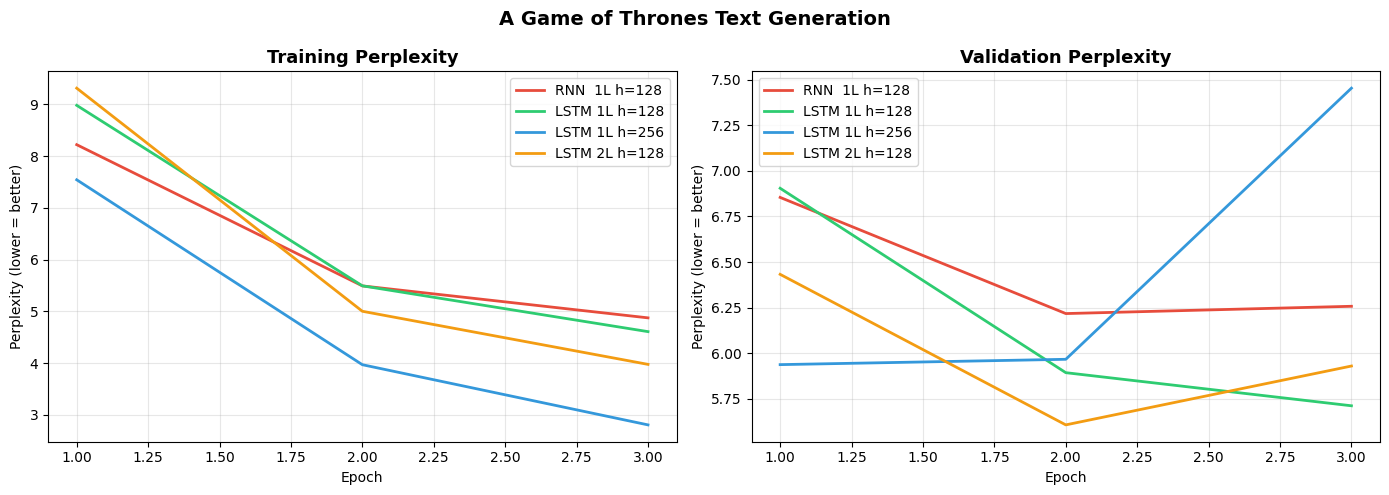

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

for (label, hist), color in zip(all_histories.items(), colors):
    epochs = range(1, len(hist['train_ppl']) + 1)
    axes[0].plot(epochs, hist['train_ppl'], label=label, color=color, linewidth=2)
    axes[1].plot(epochs, hist['val_ppl'],   label=label, color=color, linewidth=2)

for ax, title in zip(axes, ['Training Perplexity', 'Validation Perplexity']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity (lower = better)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('A Game of Thrones Text Generation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 10.) Text Generation — Temperature Sampling

From the Large Language Model lecture: `y = softmax(u/τ)`
- τ = 0.5 → focused, repetitive
- τ = 1.0 → balanced
- τ = 1.5 → creative, random

In [103]:
best_model = trained_models[best_name]
SEED_TEXT  = 'the night was dark and full of terrors'

print(f'Best model: {best_name}\nSeed: "{SEED_TEXT}"\n')
for tau in [0.5, 1.0, 1.5]:
    print(f'{"─"*55}\nTemperature τ = {tau}\n{"─"*55}')
    print(generate_text(best_model, SEED_TEXT, n_chars=400, temperature=tau))
    print()

Best model: LSTM 2L h=128
Seed: "the night was dark and full of terrors"

───────────────────────────────────────────────────────
Temperature τ = 0.5
───────────────────────────────────────────────────────
the night was dark and full of terrors that the sapped the softly of the dead is a strange and sonts sightly. 
"and his long and store it was the cegter of the forest was rider before the land to a is long anst and faces with a dorne of the said. "the silly was day and hands. the said. "we was not for his dead was the sons and the dragon to see the need. 
will was to to to will sicked it touched him thee down that the man with somethi

───────────────────────────────────────────────────────
Temperature τ = 1.0
───────────────────────────────────────────────────────
the night was dark and full of terrors, if 
dlad of 
them. 
the raggen men bronood robed you samp of nerling of it eness faster beath. will kive a netble's litter, but every garing." 
"ih as he wend brothed her. 
the close

# 11.) Text Generation - Top-k Sampling

In [106]:
def generate_text(model, seed, n_chars=400, temperature=1.0, top_k=None):
    model.eval()
    x = torch.tensor([char_to_int.get(c, 0) for c in seed.lower()],
                     dtype=torch.long).unsqueeze(0).to(DEVICE)
    h   = model.init_hidden(1)
    gen = list(seed)
    with torch.no_grad():
        _, h = model(x, h)
        nxt  = x[:, -1:]
        for _ in range(n_chars):
            logits, h = model(nxt, h)
            logits    = logits[:, -1, :] / temperature
            if top_k:
                # Ensure top_k does not exceed the vocabulary size
                current_top_k = min(top_k, logits.size(-1))
                v, _ = torch.topk(logits, current_top_k)
                logits = logits.masked_fill(logits < v[:, -1:], float('-inf'))
            idx = torch.multinomial(torch.softmax(logits, dim=-1), 1).item()
            gen.append(int_to_char[idx])
            nxt = torch.tensor([[idx]], dtype=torch.long).to(DEVICE)
    return ''.join(gen)

for k in [5, 20, 50]:
    print(f'{"─"*55}\nTop-k = {k}  (τ = 1.0)\n{"─"*55}')
    print(generate_text(best_model, SEED_TEXT, n_chars=400, temperature=1.0, top_k=k))
    print()

───────────────────────────────────────────────────────
Top-k = 5  (τ = 1.0)
───────────────────────────────────────────────────────
the night was dark and full of terrors him, the cheles with the children to his father seemed than the was. the came in the warning beto he see the seven touching a for him. 
"the stood and hels and bran were," with where he sinks, that had he house the soff at the warn, the foring as his said, but the sons troun all thoog they moved, it wouts and he had been, whine what had bronget, and a dark on thought the saud of the cholked a far

───────────────────────────────────────────────────────
Top-k = 20  (τ = 1.0)
───────────────────────────────────────────────────────
the night was dark and full of terrors the pusted tonerhan." 
"i grood 
that. "wser forcest on the hild was and almus was ever now. the wood would watch," he shouldled destar of right to something other want. she was champen and forth to scrogst of the aychilb, and when he was anwhere. for th

# 12.) Conducting my own experiment

In [107]:
MY_SEED        = 'The Summer Soltice is less than a month away.'
MY_TEMPERATURE = 1.0
MY_TOP_K       = 20
MY_LENGTH      = 500

print(generate_text(best_model, MY_SEED, MY_LENGTH, MY_TEMPERATURE, MY_TOP_K))

The Summer Soltice is less than a month away. they father gown, her took better they a shill cont strouned and you luter the want as a sertiyce men, said your fertine, him. "and in my for witclow leaple and not 
enough, you divere that did lask and blood of weron could selen's tamuse did not have the ones of 
dead brother of her beat like," lorge cound be. 
sharpyraaned them of he went to mishing had said. "the bust we, ham when the party of horee there and woman a secly-horses, hir. he wapming a dark aword they last shought. jon bloovad b


# 13.) Final Test Results

In [110]:
test_loss, test_ppl = run_epoch(best_model, test_loader)

print(f'{"─"*40}')
print(f'      Final Test Results')
print(f'{"─"*40}')
print(f'  Model:     {best_name}')
print(f'  Test Loss: {test_loss:.4f}')
print(f'  Test PPL:  {test_ppl:.2f}')
print(f'{"─"*40}')
print(f'  Lower PPL = better model')
print(f'  PPL ≈ avg choices per character: ~{test_ppl:.0f}')

────────────────────────────────────────
      Final Test Results
────────────────────────────────────────
  Model:     LSTM 2L h=128
  Test Loss: 1.6615
  Test PPL:  5.27
────────────────────────────────────────
  Lower PPL = better model
  PPL ≈ avg choices per character: ~5
